In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data =pd.read_csv("Ecommerce Customers.csv")

data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [2]:
#understanding your data/ Analysing oyour data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
None


In [7]:
data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


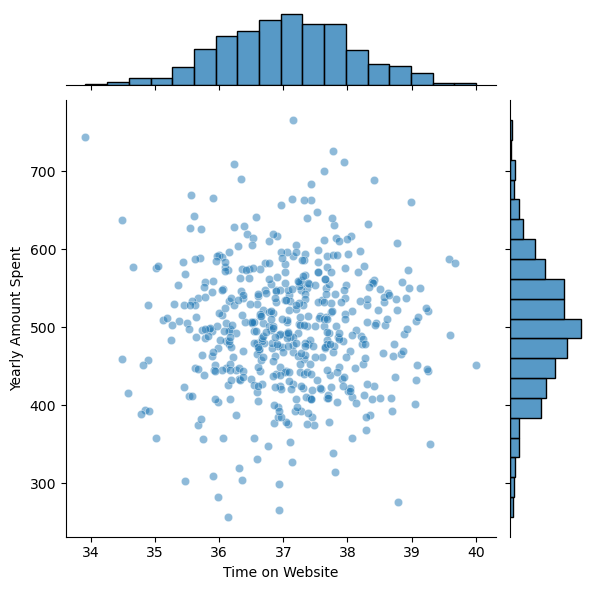

In [11]:
#EDA

sns.jointplot(x="Time on Website", y="Yearly Amount Spent", data=data, alpha=0.5)

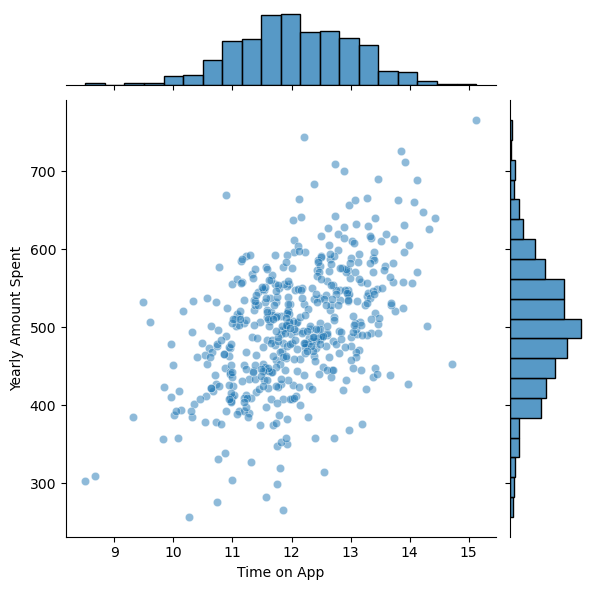

In [12]:
sns.jointplot(x="Time on App", y="Yearly Amount Spent", data=data, alpha=0.5)

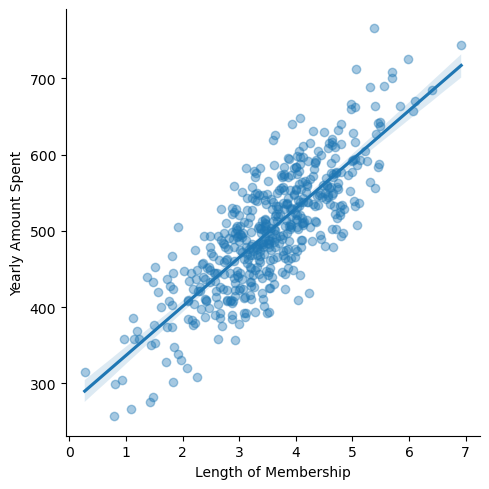

In [15]:
sns.lmplot( x ='Length of Membership',
            y='Yearly Amount Spent',
            data=data,
            scatter_kws={'alpha':0.4})

In [21]:
#Model creation
from sklearn.model_selection import train_test_split

X =data[['Time on App','Avg. Session Length','Time on Website','Length of Membership']]
y = data['Yearly Amount Spent']


X_test,X_train,y_test,y_train =train_test_split(X,y, test_size=0.3,random_state=42)

X_train


,Time on App,Avg. Session Length,Time on Website,Length of Membership
5,12.026925,33.871038,34.476878,5.493507
116,12.011022,33.925795,36.701052,2.753424
45,12.170525,34.555768,39.131097,3.663105
16,11.733862,32.125387,34.894093,3.136133
462,11.233415,33.503810,37.211153,2.320550
...,...,...,...,...
106,12.190474,32.291756,36.152462,3.781823
270,12.956277,34.006489,38.655095,3.275734
348,10.886921,31.812483,34.897828,3.128639
435,14.132893,32.259973,37.023479,3.762070


In [24]:
#training model

from sklearn.linear_model import LinearRegression

#model
lm =LinearRegression()

#fitting my model

lm.fit(X_train,y_train)
lm.coef_




array([38.97001626, 25.82322636,  0.59739525, 61.14499681])

In [27]:
cdata =pd.DataFrame(lm.coef_,X.columns, columns = ["Coef"])
print(cdata)

                           Coef
Time on App           38.970016
Avg. Session Length   25.823226
Time on Website        0.597395
Length of Membership  61.144997


In [28]:
#predictions

predictions= lm.predict(X_test)
predictions

array([636.65282115, 471.23340885, 550.79136122, 436.26137251,
       403.86970989, 468.09890201, 569.97939005, 421.58927298,
       499.1161868 , 605.04948552, 460.67370684, 572.27391299,
       557.43038921, 570.22778043, 449.18218322, 541.6199909 ,
       607.11597236, 557.0537067 , 478.45797215, 555.41916548,
       485.75520686, 749.64260875, 336.67087502, 504.36627999,
       640.08270257, 379.86915482, 425.33532501, 552.79434105,
       477.83777163, 524.6149183 , 550.89550259, 415.71814387,
       496.38142882, 565.88303878, 448.07631225, 463.59695179,
       587.44113944, 477.21643694, 500.19183803, 524.5671564 ,
       608.90614654, 474.99218583, 655.91475285, 573.46138586,
       548.34975706, 460.21979072, 514.33713899, 521.57878616,
       556.3950054 , 394.1149977 , 421.69435992, 336.9688549 ,
       395.01517352, 507.2652055 , 493.03375997, 470.61164392,
       455.74086667, 563.28226621, 486.24904353, 397.94304311,
       524.6530266 , 575.93931578, 477.13808863, 286.91

Text(0.5, 0, 'Pedictions')

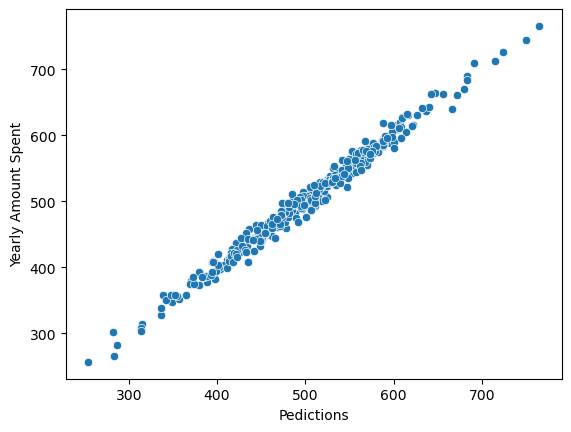

In [31]:
sns.scatterplot(x=predictions, y= y_test)
plt.xlabel("Pedictions")
plt.tittle("Evaluation of our ML")

In [33]:
#Evaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print("Mean square erroe", mean_squared_error(y_test, predictions))
print("Mean absolute erroe", mean_absolute_error(y_test, predictions))
print("RMSE:", math.sqrt(mean_squared_error(y_test,predictions)))



Mean square erroe 99.30810314181812
Mean absolute erroe 7.785715192370824
RMSE: 9.965345109017456


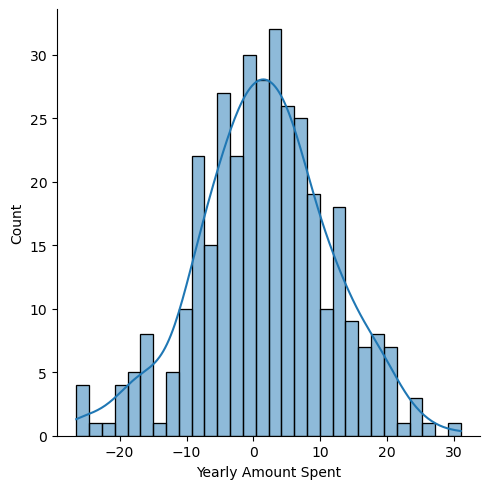

In [36]:
#evauationg residuals(testing normality)

residuals = y_test  - predictions

sns.displot(residuals, bins=30, kde=True)



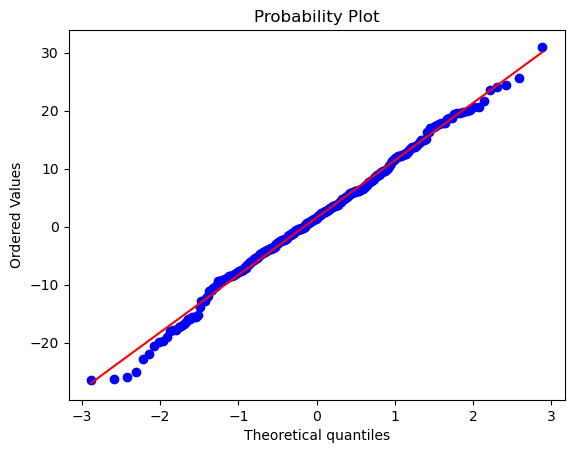

In [38]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist ="norm", plot=pylab )
pylab.show()
